# 1. Imports

This function block allows you to import the data tables present on the shared GitHub repository

In [1]:
!git clone https://github.com/JoeChen322/Fintech.git
%cd Fintech

C:\Users\Maxime\Documents\Milan\Fintech\BusinessCase2\Fintech\Fintech


Cloning into 'Fintech'...
Updating files:  46% (22/47)
Updating files:  48% (23/47)
Updating files:  51% (24/47)
Updating files:  53% (25/47)
Updating files:  55% (26/47)
Updating files:  57% (27/47)
Updating files:  59% (28/47)
Updating files:  61% (29/47)
Updating files:  63% (30/47)
Updating files:  65% (31/47)
Updating files:  68% (32/47)
Updating files:  70% (33/47)
Updating files:  72% (34/47)
Updating files:  74% (35/47)
Updating files:  76% (36/47)
Updating files:  78% (37/47)
Updating files:  80% (38/47)
Updating files:  82% (39/47)
Updating files:  85% (40/47)
Updating files:  87% (41/47)
Updating files:  89% (42/47)
Updating files:  91% (43/47)
Updating files:  93% (44/47)
Updating files:  95% (45/47)
Updating files:  97% (46/47)
Updating files: 100% (47/47)
Updating files: 100% (47/47), done.


In [50]:
import pandas as pd
from typing import List, Dict, Optional, Tuple
from dataclasses import dataclass
import seaborn as sns
import math
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.manifold import TSNE
from scipy import stats
from scipy.stats import chi2_contingency, skew, shapiro, normaltest


# 2. Configuration

The next cells aim to load the Excel workbook and separate the sheets into:
   - the main client dataset : needs_df
   - the products catalogue : products_df
   - the metadata table : metadata_df
  
Initially, we will analyze the need_df table containing the data of the different clients. We are going to inspect structure and variable meaning of this specific table.

In [18]:
needs_df = pd.read_excel("Dataset2_Needs.xls", sheet_name="Needs")
products_df = pd.read_excel("Dataset2_Needs.xls", sheet_name="Products")

# The metadata retrieved is that relating to the needs_df database
metadata_df = pd.read_excel("Dataset2_Needs.xls", sheet_name="Metadata", nrows=11)

# We delete the first line, which doesn't serve much purpose
metadata_df = metadata_df[metadata_df["Metadata"] != "Clients"]

# We remove any potentially unnecessary spaces at the beginning and end of each column name.
#(An unwanted space was present in "income ")
needs_df.columns = needs_df.columns.str.strip()
products_df.columns = products_df.columns.str.strip()
metadata_df.columns = metadata_df.columns.str.strip()

# List of categorical columns in the dataset:
CATEGORICAL_COLS = ["Gender"]

# List of numeric columns in the dataset:
NUMERIC_COLS = ["Age", "FamilyMembers", "FinancialEducation", "RiskPropensity", "Income", "Wealth"]

# List of target columns in the dataset:
TARGET_COLS = ["IncomeInvestment", "AccumulationInvestment"]

# Value mapping: introduces dictionaries to convert numeric codes into readable labels
VALUE_MAPS: Dict[str, Dict[int, str]] = {
    "Gender": {0: "Male", 1: "Female"},
    "AccumulationInvestment": {0:"Low propensity", 1: "High propensity"},
    "IncomeInvestment": {0:"Low propensity", 1: "High propensity"}
}

needs_df.head()

,ID,Age,Gender,FamilyMembers,FinancialEducation,RiskPropensity,Income,Wealth,IncomeInvestment,AccumulationInvestment
0,1,60,0,2,0.228685,0.233355,68.181525,53.260067,0,1
1,2,78,0,2,0.358916,0.170911,21.807595,135.550048,1,0
2,3,33,1,2,0.317515,0.249703,23.252747,66.303678,0,1
3,4,69,1,4,0.767685,0.654597,166.189034,404.997689,1,1
4,5,58,0,3,0.429719,0.349039,21.186723,58.911930,0,0


In [19]:
products_df.head()

,IDProduct,Type,Risk
0,1,1,0.55
1,2,0,0.30
2,3,0,0.12
3,4,0,0.44
4,5,1,0.41


In [20]:
metadata_df.head(20)

,Metadata,Unnamed: 1
1,ID,Numerical ID
2,Age,"Age, in years"
3,Gender,"Gender (Female = 1, Male = 0)"
4,FamilyMembers,Number of components
5,FinancialEducation,Normalized level of Financial Education (estim...
6,RiskPropensity,Normalized Risk propensity from MIFID profile
7,Income,Income (thousands of euros); estimate
8,Wealth,Wealth (thousands of euros); sum of investment...
9,IncomeInvestment,Boolean variable for Income investment; 1 = Hi...
10,AccumulationInvestment,Boolean variable for Accumulation/growth inves...


# 3. Cleaning functions

In [21]:
# Dataclass used to store the cleaned and prepared dataset
@dataclass
class PreparedFeatures:
    # Final prepared dataset of features after preprocessing
    X: pd.DataFrame

    # Metadata associated with this dataset (feature descriptions, etc.)
    features_metadata_df: pd.DataFrame

    # List of numerical columns kept in the dataset
    numeric_cols: List[str]

    # List of categorical columns kept in the dataset
    categorical_cols: List[str]

    # Columns that have zero variance
    removed_zero_variance_cols: List[str]

    # Columns with very low variance
    near_zero_variance_cols: List[str]

    # Audit log describing the preprocessing steps that were applied
    audit_lines: List[str]



@dataclass
class PreparedTargets:
    # Final prepared dataset of targets values after preprocessing
    Y: pd.DataFrame

    # Metadata associated with this dataset (feature descriptions, etc.)
    targets_metadata_df: pd.DataFrame

    # List of indexes retained in the dataset after removing rows with missing IncomeInvestment and AccumulationInvest values
    kept_index: pd.Index

    # number of lines with NaN value
    dropped_rows_missing_target: int

    # Audit log describing the preprocessing steps that were applied
    audit_lines: List[str]


@dataclass
class OutlierDetectionResult:
    # Dataset of features after potentially removing the outliers
    X_inliers: pd.DataFrame

    # Dataset of target values after potentially removing the outliers
    Y_inliers: pd.DataFrame

    # Column associating 1 if the point is considered normal, -1 otherwise
    full_outlier_labels: pd.Series

    # Anomaly score for each observation
    full_anomaly_scores: pd.Series

    # Number of outliers detected
    outlier_count: int

    # Porportion of outliers
    outlier_rate: float

    # Audit log describing the preprocessing steps that were applied
    audit_lines: List[str]

The following code allows you to create two new datasets, one containing all the features and customer data, the other containing the target variables

In [22]:
def split_features_and_targets(data: pd.DataFrame, target_cols: List[str] = TARGET_COLS) -> Tuple[pd.DataFrame, pd.DataFrame]:

    Y = data[target_cols].copy()

    drop_cols = target_cols.copy()
    X = data.drop(columns=drop_cols, errors="ignore").copy()

    return X, Y

In [23]:
X, Y = split_features_and_targets(data=needs_df)

targets_metadata_df = metadata_df[
    metadata_df["Metadata"].isin(TARGET_COLS)
].reset_index(drop=True)

features_metadata_df = metadata_df[
    ~metadata_df["Metadata"].isin(TARGET_COLS)
].reset_index(drop=True)

In [24]:
features_metadata_df.head()

,Metadata,Unnamed: 1
0,ID,Numerical ID
1,Age,"Age, in years"
2,Gender,"Gender (Female = 1, Male = 0)"
3,FamilyMembers,Number of components
4,FinancialEducation,Normalized level of Financial Education (estim...


In [25]:
targets_metadata_df.head()

,Metadata,Unnamed: 1
0,IncomeInvestment,Boolean variable for Income investment; 1 = Hi...
1,AccumulationInvestment,Boolean variable for Accumulation/growth inves...


In [26]:
X.head()

,ID,Age,Gender,FamilyMembers,FinancialEducation,RiskPropensity,Income,Wealth
0,1,60,0,2,0.228685,0.233355,68.181525,53.260067
1,2,78,0,2,0.358916,0.170911,21.807595,135.550048
2,3,33,1,2,0.317515,0.249703,23.252747,66.303678
3,4,69,1,4,0.767685,0.654597,166.189034,404.997689
4,5,58,0,3,0.429719,0.349039,21.186723,58.911930


In [27]:
Y.head()

,IncomeInvestment,AccumulationInvestment
0,0,1
1,1,0
2,0,1
3,1,1
4,0,0


In [28]:
# Detect different forms of missing values and replaces them with np.nan
def normalize_missing_tokens(df: pd.DataFrame) -> pd.DataFrame:
    tokens = {"", " ", "NA", "N/A", "na", "n/a", "null", "None", "none", "-", "--"}
    out = df.copy()
    for col in out.columns:
        if out[col].dtype == object:
            out[col] = out[col].replace(list(tokens), np.nan)
    return out

# Detect whether a feature has near-zero variance
def detect_near_zero_variance(series: pd.Series) -> bool:
    s = series.dropna()
    counts = s.value_counts()

    # Compute the ratio between the most frequent and second most frequent values
    freq_ratio = counts.iloc[0] / max(counts.iloc[1], 1)

    # Compute the ratio between the number of different values and the total number of observations used to measure the diversity of values in this feature
    pct_unique = s.nunique() / len(s)
    return (freq_ratio >= 20) and (pct_unique <= 0.10)


def clean_and_audit_data(data: pd.DataFrame, features_metadata_df: pd.DataFrame, categorical_cols: List[str] = CATEGORICAL_COLS, numeric_cols: List[str] = NUMERIC_COLS, value_maps: Dict[str, Dict[int, str]] = VALUE_MAPS) -> PreparedFeatures:
    # Initialize an audit log to keep track of all cleaning steps
    audit_lines: List[str] = []

    # Create a working copy of the dataset and standardize missing-value tokens
    df = normalize_missing_tokens(data.copy())

    # Start audit report
    audit_lines.append("DATA AUDIT")
    audit_lines.append("=" * 80)
    audit_lines.append(f"Initial X shape (dataset of features): {df.shape}")

    # Remove fully duplicated rows
    exact_dupes = int(df.duplicated().sum())
    if exact_dupes > 0:
        df = df.drop_duplicates().copy()
    audit_lines.append(f"Exact duplicate rows removed: {exact_dupes}")

    # Remove duplicated IDs, keeping only the first occurrence
    duplicate_ids = int(df["ID"].duplicated().sum())
    if duplicate_ids > 0:
        df = df.drop_duplicates(subset=["ID"], keep="first").copy()
    audit_lines.append(f"Duplicate IDs removed: {duplicate_ids}")

    # Delete the columns 'ID' that doesn't contains any usefull information for the clustering
    df = df.drop(columns=['ID'])

    # Identify categorical columns
    # Identify numeric columns by excluding ID and categorical columns
    categorical_cols = [c for c in categorical_cols if c in df.columns]
    numeric_cols = [c for c in numeric_cols if c in df.columns]

    # Convert columns to numeric (for instance "2" to 2). Invalid values become NaN
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")


    # Validate categorical codes against allowed values defined in VALUE_MAPS
    # All invalid values become: NaN
    audit_lines.append("Invalid categorical codes replaced with missing values:")
    for col in categorical_cols:
        allowed = set(value_maps[col].keys()) if col in value_maps else None
        invalid_mask = ~df[col].isin(allowed) & df[col].notna()
        invalid_count = int(invalid_mask.sum())
        if invalid_count > 0:
            df.loc[invalid_mask, col] = np.nan
        audit_lines.append(f"  - {col}: {invalid_count}")


    # Record missing values before imputation
    audit_lines.append("Missing values before imputation:")
    for col, val in df.isna().sum().items():
        audit_lines.append(f"  - {col}: {int(val)}")

    # Impute missing numeric values with the median
    for col in numeric_cols:
        if df[col].isna().any():
            df[col] = df[col].fillna(df[col].median())

    # Impute missing categorical values with the most frquence value taken
    # If this value doesn't exist, it uses a fallback value defined from the allowed categories (VALUE_MAPS)
    # Finaly convert the entire column to ensure a consistent format usable by algorithms
    for col in categorical_cols:
        if df[col].isna().any():
            mode_value = df[col].mode(dropna=True)
            fallback = sorted(value_maps[col].keys())[0]
            fill_value = int(mode_value.iloc[0]) if not mode_value.empty else fallback
            df[col] = df[col].fillna(fill_value)

        df[col] = df[col].astype(int)

    # Record missing values after imputation
    audit_lines.append("Missing values after imputation:")
    for col, val in df.isna().sum().items():
        audit_lines.append(f"  - {col}: {int(val)}")

    # Detect zero-variance and near-zero-variance features
    removed_zero_variance_cols: List[str] = []
    near_zero_variance_cols: List[str] = []

    # Iterate through the columns
    # Save them that contained only a single value (and therefore having a variance of 0) in the list removed_zero_variance_cols
    # Save them that detecte as "near zero variance" in the list near_zero_variance_cols
    for col in df.columns:
        if df[col].nunique(dropna=False) <= 1:
            removed_zero_variance_cols.append(col)
        elif detect_near_zero_variance(df[col]):
            near_zero_variance_cols.append(col)

    # Remove zero-variance columns
    if removed_zero_variance_cols:
        df = df.drop(columns=removed_zero_variance_cols).copy()

    # Remove near-zero-variance columns
    if near_zero_variance_cols:
        df = df.drop(columns=near_zero_variance_cols).copy()

    audit_lines.append(
        "Zero-variance columns removed: "
        + (", ".join(removed_zero_variance_cols) if removed_zero_variance_cols else "none")
    )
    audit_lines.append(
        "Near-zero-variance columns removed: "
        + (", ".join(near_zero_variance_cols) if near_zero_variance_cols else "none")
    )

    # Update column lists after removing zero-variance and near-zero-variance columns
    categorical_cols = [c for c in categorical_cols if c not in removed_zero_variance_cols]
    numeric_cols = [c for c in numeric_cols if c not in removed_zero_variance_cols]

    # Compute absolute correlation matrix for numeric features
    if numeric_cols:
        corr = df[numeric_cols].corr().abs()
        high_corr = []

        for i in range(len(corr.columns)):
            for j in range(i + 1, len(corr.columns)):
                if corr.iloc[i, j] >= 0.85:
                    high_corr.append((corr.index[i], corr.columns[j], float(corr.iloc[i, j])))

        if high_corr:
            audit_lines.append("High-correlation numeric pairs flagged (not auto-removed):")
            for a, b, r in high_corr:
                audit_lines.append(f"  - {a} vs {b}: {r:.3f}")
        else:
            audit_lines.append("High-correlation numeric pairs flagged: none above 0.85")
    else:
        audit_lines.append("High-correlation numeric pairs flagged: no numeric columns available")

    audit_lines.append(f"Final shape after cleaning: {df.shape}")

    return PreparedFeatures(
        X=df,
        features_metadata_df=features_metadata_df,
        numeric_cols=numeric_cols,
        categorical_cols=categorical_cols,
        removed_zero_variance_cols=removed_zero_variance_cols,
        near_zero_variance_cols=near_zero_variance_cols,
        audit_lines=audit_lines,
    )

Binary target processing :

In [29]:
def prepare_binary_targets(data: pd.DataFrame, targets_metadata_df: pd.DataFrame, target_cols: List[str] = TARGET_COLS, value_maps: Dict[str, Dict[int, str]] = VALUE_MAPS) -> PreparedTargets:
    # Initialize an audit log to keep track of all cleaning steps
    audit_lines: List[str] = []

    # Create a working copy of the dataset and standardize missing-value tokens
    df = normalize_missing_tokens(data.copy())

    # Start audit report
    audit_lines.append("DATA AUDIT")
    audit_lines.append("=" * 80)
    audit_lines.append(f"Initial Y shape (dataset of targets): {df.shape}")

    audit_lines.append(f"Invalid target codes replaced with missing values")
    for col in df.columns:
        # Convert columns to numeric (for instance "2" to 2). Invalid values become NaN
        df[col] = pd.to_numeric(df[col], errors="coerce")


        # Validate values against allowed values defined in VALUE_MAPS
        # All invalid values become: NaN
        allowed = set(value_maps[col].keys())
        invalid_mask = ~df[col].isin(allowed) & df[col].notna()
        invalid_count = int(invalid_mask.sum())
        if invalid_count > 0:
            df.loc[invalid_mask, col] = np.nan

        audit_lines.append(f"  - {col}: {invalid_count}")

    audit_lines.append("Missing values in targets before filtering:")
    for col, val in df.isna().sum().items():
        audit_lines.append(f"  - {col}: {int(val)}")

    # Remove the lines where a target is missing
    mask_complete_targets = df.notna().all(axis=1)

    # number of lines with NaN value
    dropped_rows = int((~mask_complete_targets).sum())

    df = df.loc[mask_complete_targets].copy()

    # List of retained indexes
    kept_index = df.index

    # Conversion finale en int
    for col in df.columns:
        df[col] = df[col].astype(int)

    audit_lines.append(f"Rows dropped because of missing target(s): {dropped_rows}")
    audit_lines.append(f"Final y shape after filtering: {df.shape}")

    return PreparedTargets(
        Y=df,
        targets_metadata_df=targets_metadata_df,
        kept_index=kept_index,
        dropped_rows_missing_target=dropped_rows,
        audit_lines=audit_lines,
    )

In [30]:
prepared_Y = prepare_binary_targets(data=Y,targets_metadata_df=targets_metadata_df)

# We filter raw X based on the rows retained in Y
X_filtered = X.loc[prepared_Y.kept_index].copy()

prepared_X = clean_and_audit_data(data=X_filtered,features_metadata_df=features_metadata_df)

# Sécurité finale : on réaligne Y sur les lignes réellement conservées dans X
X_clean = prepared_X.X
Y_clean = prepared_Y.Y.loc[X_clean.index].copy()

In [31]:
X_clean.head()

,Age,Gender,FamilyMembers,FinancialEducation,RiskPropensity,Income,Wealth
0,60,0,2,0.228685,0.233355,68.181525,53.260067
1,78,0,2,0.358916,0.170911,21.807595,135.550048
2,33,1,2,0.317515,0.249703,23.252747,66.303678
3,69,1,4,0.767685,0.654597,166.189034,404.997689
4,58,0,3,0.429719,0.349039,21.186723,58.911930


In [32]:
Y_clean.head()

,IncomeInvestment,AccumulationInvestment
0,0,1
1,1,0
2,0,1
3,1,1
4,0,0


In [33]:
print("\n".join(prepared_X.audit_lines))
print()
print("\n".join(prepared_Y.audit_lines))

DATA AUDIT
Initial X shape (dataset of features): (5000, 8)
Exact duplicate rows removed: 0
Duplicate IDs removed: 0
Invalid categorical codes replaced with missing values:
  - Gender: 0
Missing values before imputation:
  - Age: 0
  - Gender: 0
  - FamilyMembers: 0
  - FinancialEducation: 0
  - RiskPropensity: 0
  - Income: 0
  - Wealth: 0
Missing values after imputation:
  - Age: 0
  - Gender: 0
  - FamilyMembers: 0
  - FinancialEducation: 0
  - RiskPropensity: 0
  - Income: 0
  - Wealth: 0
Zero-variance columns removed: none
Near-zero-variance columns removed: none
High-correlation numeric pairs flagged: none above 0.85
Final shape after cleaning: (5000, 7)

DATA AUDIT
Initial Y shape (dataset of targets): (5000, 2)
Invalid target codes replaced with missing values
  - IncomeInvestment: 0
  - AccumulationInvestment: 0
Missing values in targets before filtering:
  - IncomeInvestment: 0
  - AccumulationInvestment: 0
Rows dropped because of missing target(s): 0
Final y shape after filt

# 4. Analysis of target variables

Now we focus specifically on the two targets:
- `IncomeInvestment`
- `AccumulationInvestment`

More especially, we will checs:
- how many positive vs negative cases we have for each target

This is essential because if one class largely dominates, a model can achieve high accuracy by simply predicting the majority class, without actually learning meaningful patterns.

- whether one target is more imbalanced than the other

higher imbalance generally makes the classification task harder, especially for the minority class. In such cases, accuracy becomes unreliable, and metrics like precision, recall, or F1-score are more appropriate.

- whether the targets are statistically associated

A strong association suggests overlapping investment behaviors and supports a joint modeling approach, while a weak association indicates that the targets capture different profiles and may require separate modeling

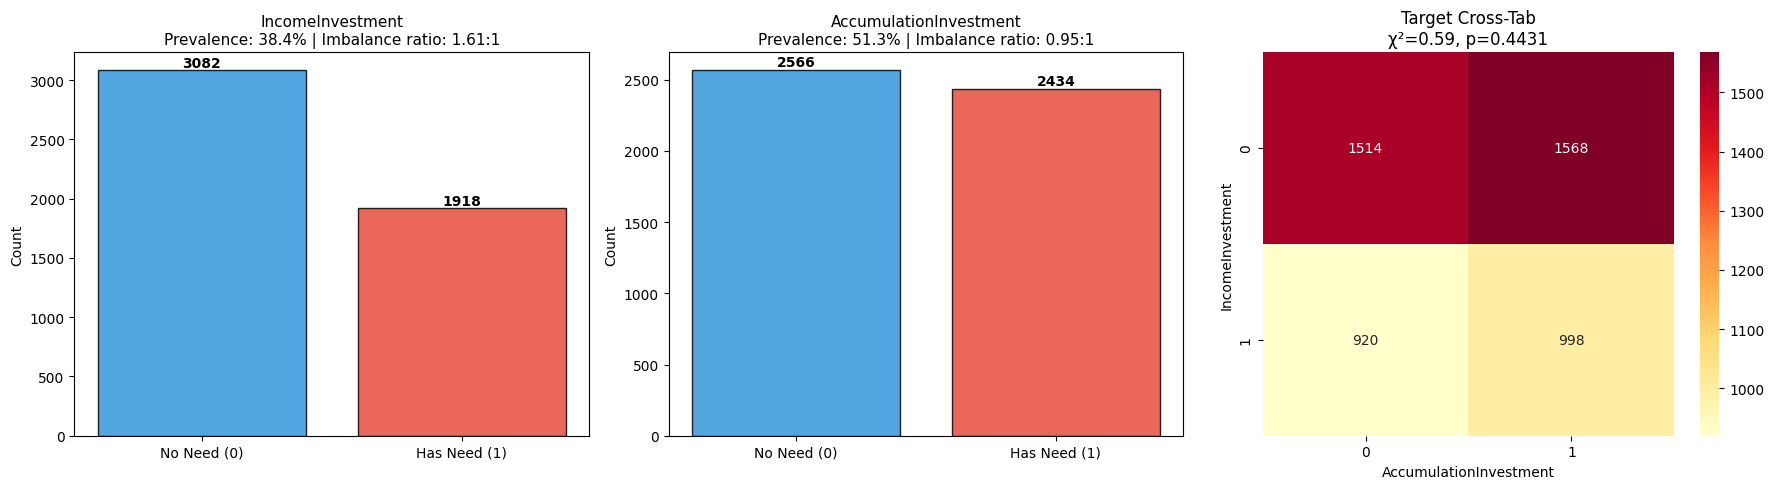

Chi-squared independence test: χ²=0.59, p=4.4306e-01
We consider that: targets are independent (α=0.05)


In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, target in zip(axes[:2], ['IncomeInvestment', 'AccumulationInvestment']):
    counts = Y_clean[target].value_counts()
    ratio = counts[1] / len(Y_clean)
    colors = ['#3498db', '#e74c3c']
    bars = ax.bar(['No Need (0)', 'Has Need (1)'], counts.values,
                   color=colors, edgecolor='black', alpha=0.85)
    ax.set_title(f'{target}\nPrevalence: {ratio:.1%} | Imbalance ratio: {counts[0]/counts[1]:.2f}:1',
                 fontsize=11)
    ax.set_ylabel('Count')
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 30, str(v),
                ha='center', fontweight='bold')



# Cross-tabulation heatmap
ct = pd.crosstab(Y_clean['IncomeInvestment'], Y_clean['AccumulationInvestment'])
chi2, p, dof, expected = chi2_contingency(ct)
sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd', ax=axes[2])
axes[2].set_title(f'Target Cross-Tab\nχ²={chi2:.2f}, p={p:.4f}')
axes[2].set_xlabel('AccumulationInvestment')
axes[2].set_ylabel('IncomeInvestment')

plt.tight_layout()
plt.show()

print(f"Chi-squared independence test: χ²={chi2:.2f}, p={p:.4e}")
print(f"We consider that: targets are {'associated' if p < 0.05 else 'independent'} (α=0.05)")

The first two graphs illustrate the proportion of Class 1 clients compared to Class 0 clients. The prevalence percentage and the imbalance rate allow us to measure the extent of this distribution.

For the first type of investment, the prevalence percentage is very low, close to 30%, while it reaches 50% for the second.

Therefore, accuracy alone is not a reliable indicator for achieving this objective. Indeed, a simplistic classifier that consistently predicts "Class 0" would already achieve an accuracy of 70%.

To assess whether the two target variables, IncomeInvestment and AccumulationInvestment, are independent, we perform a chi-squared (χ²) test of independence. This test compares the observed frequencies of each combination of the two variables with the frequencies that would be expected if they were statistically independent. The χ² statistic measures the discrepancy between these observed and expected values, and a corresponding p-value is computed to determine whether this difference is significant. If the p-value is greater than a chosen significance level (here 0.05), we do not reject the hypothesis of independence. In our case, the test indicates a high p-value, suggesting that the two variables are indeed independent and do not exhibit a statistically significant association.

# 5. Outliers detection

In this project, the use of Isolation Forest to flag outliers remains appropriate despite the presence of a categorical variable, as the only categorical feature included in the dataset is Gender, which is binary (encoded as 0 and 1). Unlike multi-class categorical variables, binary variables do not introduce misleading ordinal relationships when used in tree-based methods, since splits such as “Gender < 0.5” simply separate the two categories in a meaningful way. Furthermore, the majority of the features in the dataset are numerical, which aligns well with the assumptions underlying Isolation Forest, as it relies on random splits in a numerical feature space to isolate observations. As a result, the inclusion of a single binary variable does not significantly distort the geometry of the data nor the anomaly detection process. Therefore, Isolation Forest can be reliably applied in this context to identify atypical client profiles without introducing substantial bias.

Here, we choose to classify the 5% lowest scores as outliers.

In [35]:
def detect_outliers_isolation_forest(X: pd.DataFrame, Y: pd.DataFrame, numeric_cols: List[str] = NUMERIC_COLS, score_percentile: float = 5.0, n_estimators: int = 300, random_state: int = 42, remove_outliers: bool = False) -> OutlierDetectionResult:

    # Detect atypical observations in X with Isolation Forest, then possibly remove them from X and Y
    audit_lines: List[str] = []
    audit_lines.append("OUTLIER DETECTION WITH ISOLATION FOREST")
    audit_lines.append("=" * 80)
    audit_lines.append(f"Input X shape: {X.shape}")
    audit_lines.append(f"Score percentile threshold: {score_percentile}")
    audit_lines.append(f"n_estimators: {n_estimators}")

    # Standardize the numerical variables (excluding gender)
    X_scaled = X.copy()
    scaler = StandardScaler()
    X_scaled[numeric_cols] = scaler.fit_transform(X[numeric_cols])

    iso = IsolationForest(
        n_estimators=n_estimators,
        random_state=random_state
    )
    iso.fit(X_scaled)

    # Returns an anomaly score
    # The lower the score, the more suspicious the observation.
    scores = iso.decision_function(X_scaled)

    # Convert scores to pandas Series
    scores_series = pd.Series(scores, index=X.index, name="AnomalyScore")

    # Threshold based on the score distribution
    score_threshold = np.percentile(scores, score_percentile)

    # Build labels manually from the threshold
    # -1: atypical observation
    #  1: normal observation
    labels = np.where(scores <= score_threshold, -1, 1)
    labels_series = pd.Series(labels, index=X.index, name="OutlierLabel")

    outlier_count = int((labels_series == -1).sum())
    outlier_rate = outlier_count / len(X)

    audit_lines.append(f"Score threshold used: {score_threshold:.6f}")
    audit_lines.append(f"Outliers detected: {outlier_count}")
    audit_lines.append(f"Outlier rate: {outlier_rate:.2%}")

    if remove_outliers:
        inlier_mask = labels_series == 1
        # keep only the normal lines in X and Y
        X_inliers = X.loc[inlier_mask].copy()
        Y_inliers = Y.loc[inlier_mask].copy()
        audit_lines.append("Outliers removed from returned datasets: yes")
    else:
        X_inliers = X.copy()
        Y_inliers = Y.copy()
        audit_lines.append("Outliers removed from returned datasets: no")

    return OutlierDetectionResult(
        X_inliers=X,
        Y_inliers=Y,
        full_outlier_labels=labels_series,
        full_anomaly_scores=scores_series,
        outlier_count=outlier_count,
        outlier_rate=outlier_rate,
        audit_lines=audit_lines,
    )

In [36]:
outlier_result = detect_outliers_isolation_forest(X=X_clean, Y=Y_clean)

In [37]:
print("\n".join(outlier_result.audit_lines))

# Jeux finaux pour le modèle
X_final = outlier_result.X_inliers
Y_final = outlier_result.Y_inliers

print("\nFINAL DATA FOR MODEL")
print("=" * 80)
print(f"X_final shape: {X_final.shape}")
print(f"Y_final shape: {Y_final.shape}")

print("\nTarget distributions after filtering:")
for col in Y_final.columns:
    print(Y_final[col].value_counts(dropna=False).sort_index())

diagnostics_df = pd.DataFrame({
    "OutlierLabel": outlier_result.full_outlier_labels,
    "AnomalyScore": outlier_result.full_anomaly_scores
})

print("\nFirst rows of outlier diagnostics:")
diagnostics_df.head(10)

OUTLIER DETECTION WITH ISOLATION FOREST
Input X shape: (5000, 7)
Score percentile threshold: 5.0
n_estimators: 300
Score threshold used: -0.082109
Outliers detected: 250
Outlier rate: 5.00%
Outliers removed from returned datasets: no

FINAL DATA FOR MODEL
X_final shape: (5000, 7)
Y_final shape: (5000, 2)

Target distributions after filtering:
IncomeInvestment
0    3082
1    1918
Name: count, dtype: int64
AccumulationInvestment
0    2434
1    2566
Name: count, dtype: int64

First rows of outlier diagnostics:


,OutlierLabel,AnomalyScore
0,1,0.069370
1,1,0.005807
2,1,0.022397
3,-1,-0.137063
4,1,0.083244
5,1,0.047337
6,1,0.094361
7,1,0.044447
8,1,-0.025458
9,1,0.022178


In [38]:
def plot_outliers_tsne(outlier_result: OutlierDetectionResult, numeric_cols: List[str] = NUMERIC_COLS, perplexity: float = 30.0, random_state: int = 42, n_iter: int = 1000) -> None:
    # Displays a 2D t-SNE projection: normal points in blue and outliers in red
    # Numerical variables are standardized before projection
    X_plot = outlier_result.X_inliers.copy()
    labels = outlier_result.full_outlier_labels.copy()

    if len(numeric_cols) < 2:
        raise ValueError("At least two numeric columns are needed to calculate a t-SNE")

    X_num = X_plot[numeric_cols].copy()

    # Standardization
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_num)

    # Automatic adjustment of perplexity if the dataset is small
    n_samples = len(X_num)
    if n_samples <= 3:
        raise ValueError("The dataset is too small for a t-SNE")
    perplexity = min(perplexity, n_samples - 1)

    # t-SNE projection
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=random_state,
        max_iter=n_iter,
        init="pca"
    )
    X_tsne = tsne.fit_transform(X_scaled)

    # Final DataFrame for display
    plot_df = pd.DataFrame(
        X_tsne,
        columns=["tSNE_1", "tSNE_2"],
        index=X_plot.index
    )
    plot_df["OutlierLabel"] = labels

    normal_df = plot_df[plot_df["OutlierLabel"] == 1]
    outlier_df = plot_df[plot_df["OutlierLabel"] == -1]

    plt.figure(figsize=(9, 7))

    plt.scatter(
        normal_df["tSNE_1"],
        normal_df["tSNE_2"],
        color="blue",
        alpha=0.5,
        s=10,
        label="Normal"
    )

    plt.scatter(
        outlier_df["tSNE_1"],
        outlier_df["tSNE_2"],
        color="red",
        alpha=0.9,
        s=15,
        label="Outlier"
    )

    plt.xlabel("t-SNE dimension 1")
    plt.ylabel("t-SNE dimension 2")
    plt.title("t-SNE projection: normal points vs outliers")
    plt.legend()
    plt.grid(True)
    plt.show()

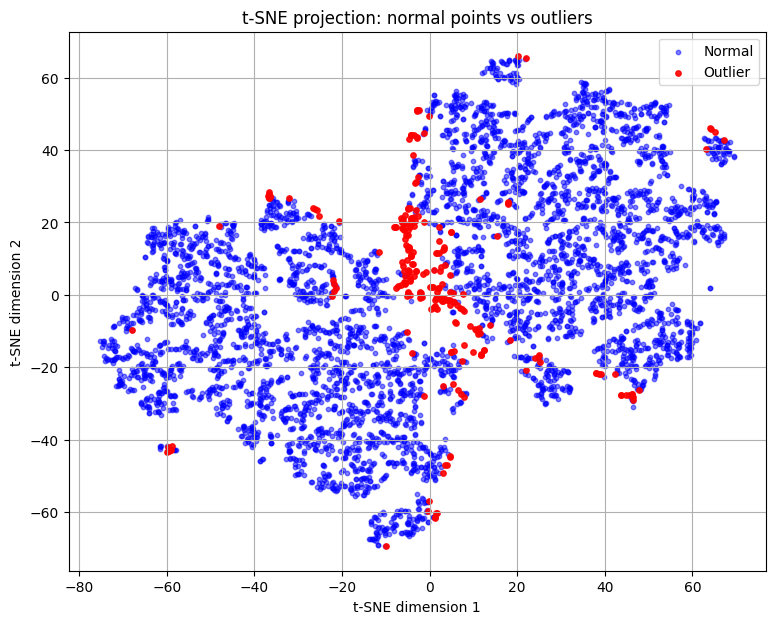

In [39]:
plot_outliers_tsne(outlier_result)

In [40]:
outliers_df = outlier_result.X_inliers[
    outlier_result.full_outlier_labels == -1
].copy()

print("\nLIST OF ALL OUTLIERS FOUND")
outliers_df.head(10)


LIST OF ALL OUTLIERS FOUND


,Age,Gender,FamilyMembers,FinancialEducation,RiskPropensity,Income,Wealth
3,69,1,4,0.767685,0.654597,166.189034,404.997689
17,80,1,1,0.119173,0.098889,6.802567,4.054744
23,81,0,2,0.595024,0.340589,156.063265,462.458278
117,25,0,1,0.571516,0.745596,3.602805,41.655649
122,87,0,4,0.157120,0.060139,13.266355,350.469602
154,78,0,2,0.130559,0.628745,36.812458,655.002664
164,82,1,3,0.222326,0.154917,144.715628,567.784795
231,32,0,4,0.134606,0.163278,196.829694,64.088322
241,76,1,4,0.245409,0.336510,162.155229,338.146963
256,78,1,1,0.156416,0.102797,170.600508,242.172707


In [41]:
def plot_outliers_2d(
    outlier_result: OutlierDetectionResult,
    feature_1: str = None,
    feature_2: str = None
) -> None:
    """
    Affiche les points normaux en bleu et les outliers en rouge
    selon deux features choisies.
    """

    X_plot = outlier_result.X_inliers.copy()
    labels = outlier_result.full_outlier_labels.copy()

    # Vérification d'alignement
    if not X_plot.index.equals(labels.index):
        common_index = X_plot.index.intersection(labels.index)
        X_plot = X_plot.loc[common_index].copy()
        labels = labels.loc[common_index].copy()

    # Si les features ne sont pas fournies, on choisit automatiquement
    numeric_cols = X_plot.select_dtypes(include="number").columns.tolist()

    if len(numeric_cols) < 2:
        raise ValueError(
            "Il faut au moins deux colonnes numériques pour faire un affichage 2D."
        )

    if feature_1 is None or feature_2 is None:
        feature_1, feature_2 = numeric_cols[0], numeric_cols[1]

    if feature_1 not in X_plot.columns or feature_2 not in X_plot.columns:
        raise ValueError("Les features choisies n'existent pas dans X_inliers.")

    plot_df = X_plot[[feature_1, feature_2]].copy()
    plot_df["OutlierLabel"] = labels

    normal_df = plot_df[plot_df["OutlierLabel"] == 1]
    outlier_df = plot_df[plot_df["OutlierLabel"] == -1]

    plt.figure(figsize=(8, 6))

    plt.scatter(
        normal_df[feature_1],
        normal_df[feature_2],
        color="blue",
        alpha=0.6,
        s=25,
        label="Normal"
    )

    plt.scatter(
        outlier_df[feature_1],
        outlier_df[feature_2],
        color="red",
        alpha=0.8,
        s=30,
        label="Outlier"
    )

    plt.xlabel(feature_1)
    plt.ylabel(feature_2)
    plt.title(f"Normal vs Outliers: {feature_1} vs {feature_2}")
    plt.legend()
    plt.grid(True)
    plt.show()

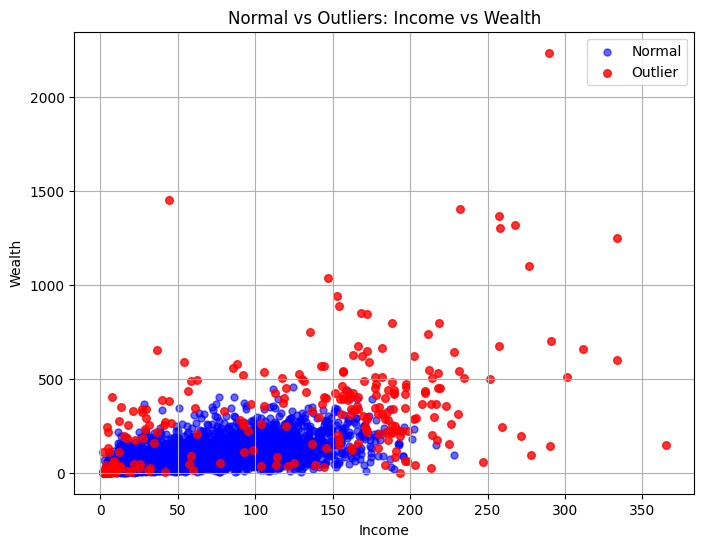

In [42]:
plot_outliers_2d(outlier_result, "Income", "Wealth")

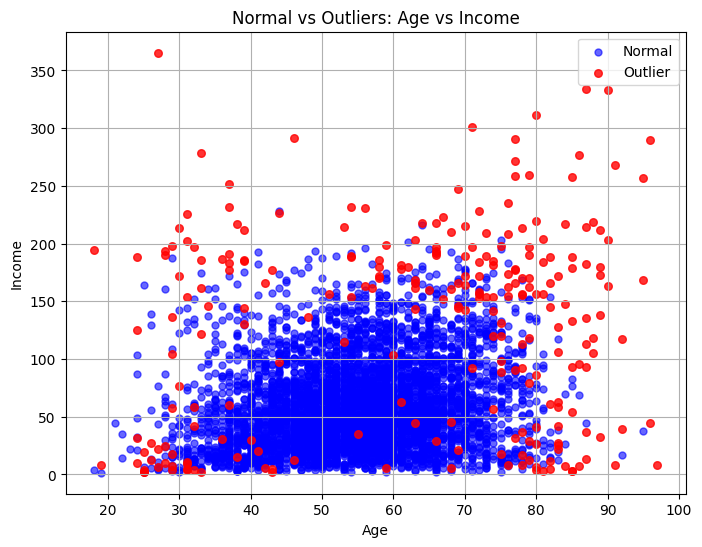

In [43]:
plot_outliers_2d(outlier_result, "Age", "Income")

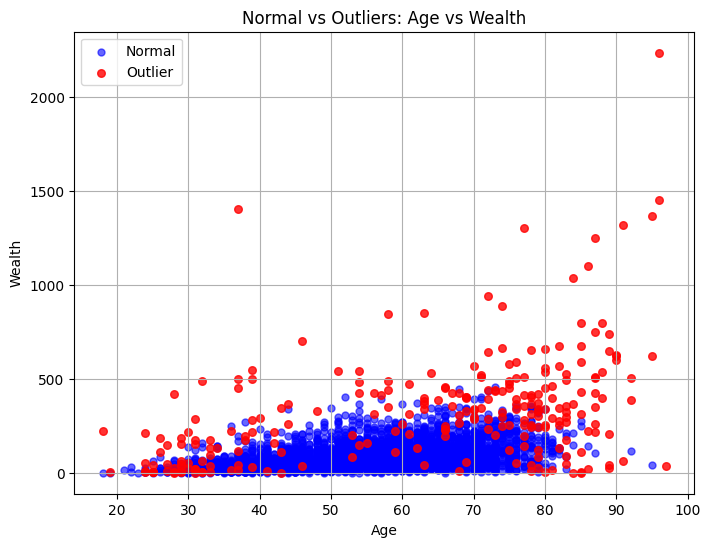

In [44]:
plot_outliers_2d(outlier_result, "Age", "Wealth")

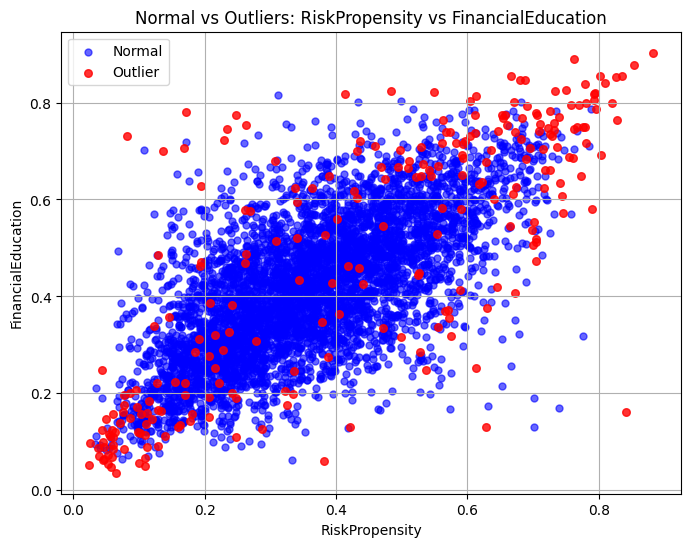

In [45]:
plot_outliers_2d(outlier_result, "RiskPropensity", "FinancialEducation")

But, in reality, financial variables such as Income and Wealth tend to have a greater influence in the analysis because they exhibit much larger scales and higher variability than other features. Their distributions are typically highly skewed, with a small number of individuals holding very large values, which creates extreme observations. As a result, these variables dominate distance-based computations and statistical measures, making them more impactful in tasks such as outlier detection or class prediction. Consequently, we will pay particular attention to these variables and conduct a detailed analysis, variable by variable.

In [46]:
desc = outlier_result.X_inliers.describe().T
desc['skewness'] = outlier_result.X_inliers.skew()
desc['kurtosis'] = outlier_result.X_inliers.kurtosis()
desc['IQR'] = desc['75%'] - desc['25%']
desc['CV'] = desc['std'] / desc['mean']  # Coefficient of variation
print(desc.round(4).to_string())

                     count     mean       std      min      25%      50%       75%        max  skewness  kurtosis      IQR      CV
Age                 5000.0  55.2534   11.9717  18.0000  47.0000  55.0000   63.0000    97.0000    0.0586   -0.0251  16.0000  0.2167
Gender              5000.0   0.4920    0.5000   0.0000   0.0000   0.0000    1.0000     1.0000    0.0320   -1.9998   1.0000  1.0162
FamilyMembers       5000.0   2.5106    0.7618   1.0000   2.0000   3.0000    3.0000     5.0000    0.0647   -0.2084   1.0000  0.3035
FinancialEducation  5000.0   0.4191    0.1514   0.0361   0.3081   0.4167    0.5234     0.9029    0.1485   -0.4221   0.2153  0.3612
RiskPropensity      5000.0   0.3627    0.1511   0.0248   0.2464   0.3545    0.4671     0.8827    0.3261   -0.3494   0.2207  0.4167
Income              5000.0  62.9943   44.3598   1.5378  30.5965  53.3994   84.1223   365.3234    1.3773    2.8560  53.5258  0.7042
Wealth              5000.0  93.8063  105.4710   1.0574  38.3111  66.0706  114.8248 

Now, we can see that the demographic features are relatively well distributed: Age is approximately symmetric around 55 years, and Gender is balanced, which is favorable for modeling. Behavioral variables such as RiskPropensity and FinancialEducation show moderate variability and are likely to contribute meaningfully to prediction. In contrast, financial variables exhibit as we predictied,strong asymmetry: Income is right-skewed, while Wealth is extremely skewed with very high kurtosis, indicating the presence of significant outliers and heavy tails.

So the high dispersion of Income and Wealth indicates that these variables are likely to be key drivers in distinguishing investment profiles.

Although Isolation Forest is more robust than distance-based methods, it remains sensitive to the distribution and scale of the features, especially for financial variables that exhibit large ranges, strong skewness, and extreme values. These characteristics can lead the algorithm to disproportionately identify high-income or high-wealth individuals as outliers. For this reason, it is important to complement Isolation Forest with exploratory tools such as histograms, box plots, and Q-Q plots. These visualizations allow us to analyze each feature individually, understand their distributions, detect skewness and outliers, and make informed decisions about appropriate transformations before applying anomaly detection methods.

# 6. Feature Distributions - Histograms, Box Plots, Q-Q Plots

This subsection focuses on understanding the behavior of each individual numerical variable through graphical analysis.

- For the main variables, the code generates histograms to visualize the overall distribution and detect skewness, box plots to identify dispersion and potential outliers per feature, and quantile-quantile plots (Q-Q plots) to assess the normality of the data.

- These visual tools are essential for diagnosing key data properties, including whether a variable approximately follows a normal distribution, exhibits strong skewness, or is affected by extreme values.

- This analysis also helps determine whether transformations, such as logarithmic scaling, are appropriate and whether standard statistical methods are suitable or if more robust nonparametric approaches are preferable.

These considerations are particularly important for financial variables, which typically exhibit thick distribution tails and significant deviations from normality.

In [47]:
def plot_distributions(outlier_result, numeric_cols):

    n = len(numeric_cols)

    # Number of graphs on a lign
    n_cols = 3

    # Number of graph on a column (as much as it's necessary to display all graphs)
    n_rows = math.ceil(n / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
    axes = axes.flatten()

    for i, feat in enumerate(numeric_cols):
        ax = axes[i]
        series = outlier_result.X_inliers[feat].dropna()

        # Plot distribution of the different numeric features
        sns.histplot(series, kde=True, ax=ax, color='steelblue', bins=40, alpha=0.7)

        # Display the mean and the median
        ax.axvline(series.mean(), color='red', ls='--', lw=1.2, label=f'mean={series.mean():.2f}')
        ax.axvline(series.median(), color='green', ls=':', lw=1.2, label=f'median={series.median():.2f}')
        ax.legend(fontsize=8)

        # Display the skwness
        ax.set_title(f'{feat} — Distribution (skew={series.skew():.2f})')

    # Delete the unecessary axes created
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

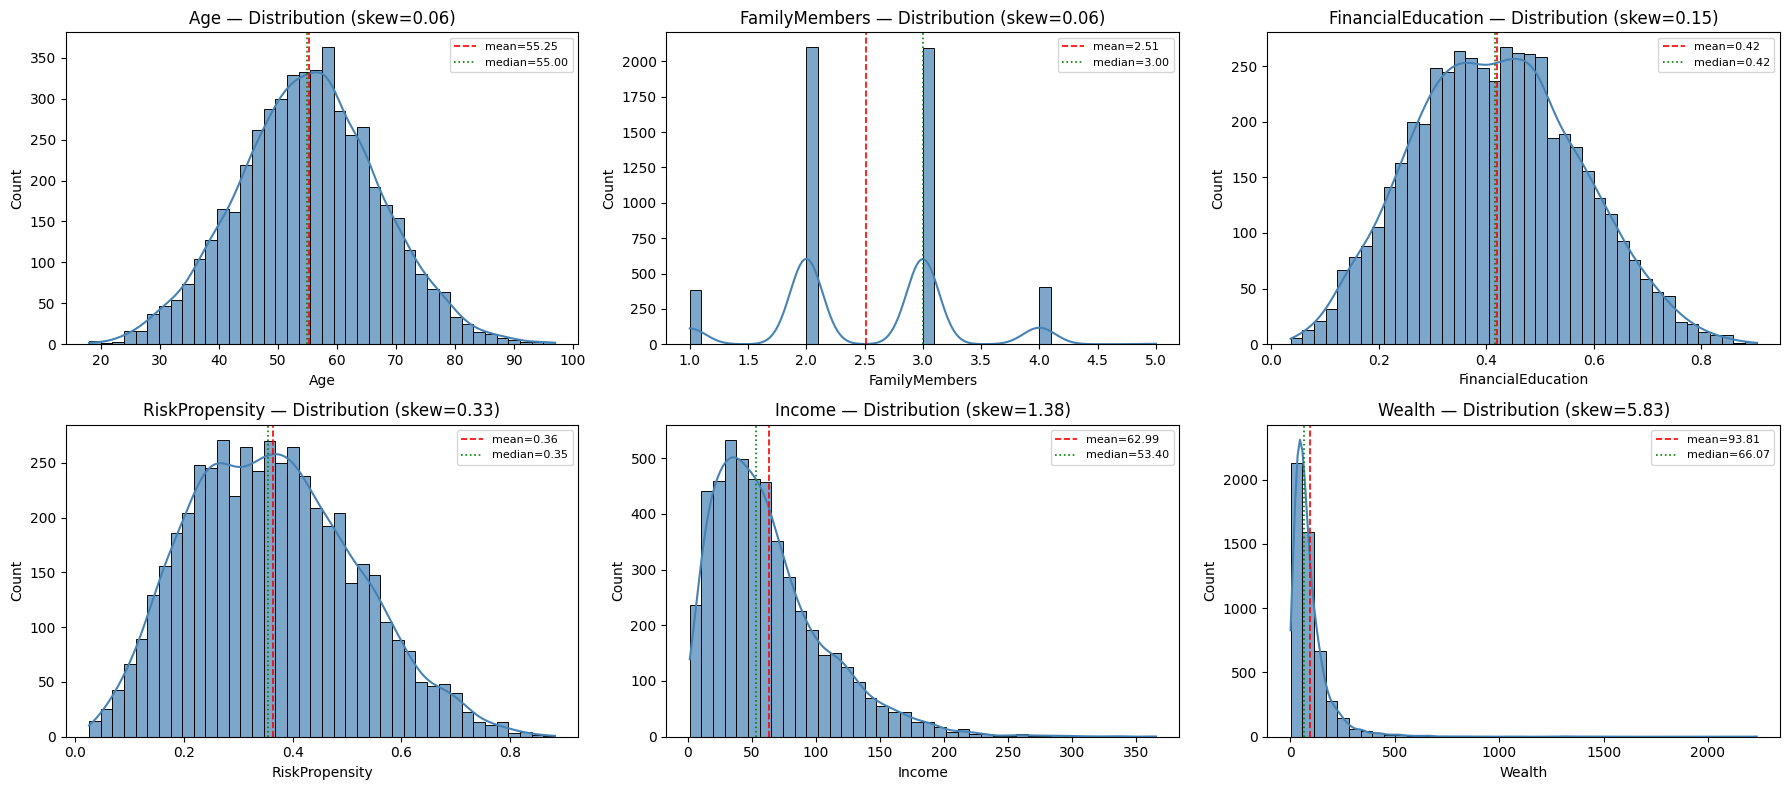

In [51]:
plot_distributions(outlier_result, NUMERIC_COLS)

Age distribution has almost a perfect symetric distribution. His skewness $0.06$ is very close to 0. So the population is well distributed around his median age. This feature is reliable, and doesnt need a data transformation.

Financial Education is also well distributed. There is a homogeneous level of financial literacy without extreme subpopulation.

RiskPropensity is slightly asymmetrical to the right. So people are usually more cautious, and the population containes few high-risk profiles.

FamilyMembers is the only one which has integer values. We observe several distinct peaks, one around 2 people (couples) and one around 3 people (families with 1 child).

However, we then notice that the Income and Wealth features exhibit strong asymmetries: $skew > 0$. Some individuals earn significantly more than the average or possess substantial wealth. The average is therefore skewed upwards and is thus much higher than the group median.

Here we will display the different box plots for each numeric feature. We will also compute $Q1$ the first quartile, $Q3$ the third quartile and $IQR = Q3 - Q1$ that measures the dispersion of the "central" observations. After, we apply $lower \space bound = Q1 - 1.5 × IQR$ and the $upper \space bound =  Q3 + 1.5 × IQR $. Each observation which isn't located between these two bounds is considered as an outlier.

In [52]:
def plot_boxplots(outlier_result, numeric_cols):

    n = len(numeric_cols)

    # Number of graphs on a lign
    n_cols = 3

    # Number of graph on a column (as much as it's necessary to display all graphs)
    n_rows = math.ceil(n / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
    axes = axes.flatten()

    for i, feat in enumerate(numeric_cols):
        ax = axes[i]
        series = outlier_result.X_inliers[feat].dropna()

        sns.boxplot(x=series, ax=ax)

        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)
        IQR = Q3 - Q1
        outliers = ((series < Q1 - 1.5 * IQR) | (series > Q3 + 1.5 * IQR)).sum()

        ax.set_title(f'{feat} — Box Plot (outliers: {outliers})')

    # Delete the unecessary axes created
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

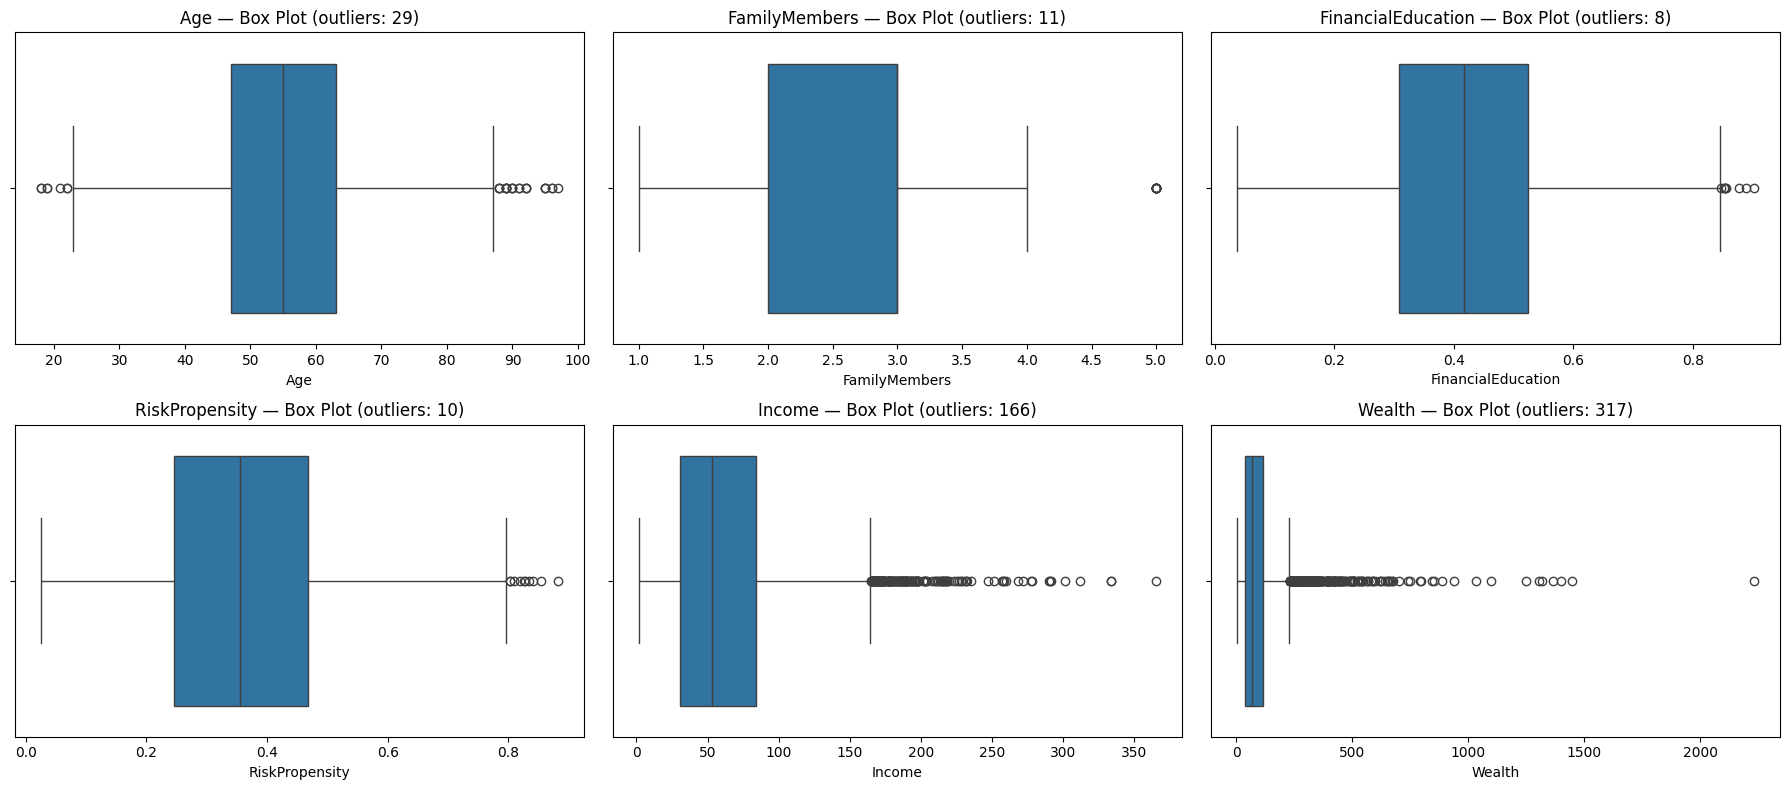

In [58]:
plot_boxplots(outlier_result, NUMERIC_COLS)

The boxplots for the first four features highlight generally well-structured distributions, but with distinct behaviors depending on the variable. 

Age shows a fairly symmetrical distribution centered around 50–60 years, with a relatively narrow interquartile range, indicating a homogeneous population. However, several extreme values are observed on both sides, indicating the presence of very young and very old individuals in our dataset. 

The number of family members is highly concentrated between 2 and 3 people, with a median close to 3. The presence of a few extreme values (notably 5) remains marginal, and the low dispersion reflects limited variability in this characteristic. 

The level of financial education is also fairly concentrated around its median (around 0.5), with moderate dispersion and a few high values considered atypical, suggesting that the majority of individuals have an intermediate level, while a minority stands out with a significantly higher level. 

Risk Propensity shows a relatively balanced distribution, with a median around 0.35–0.4 and a moderate interquartile range, indicating a majority of individuals with cautious to moderately risky behaviors; a few high values appear as outliers, reflecting a minority of highly risk-averse profiles.

Overall, these distributions indicate stable, low-noise variables, but with plausible outliers that should be interpreted as special cases rather than errors.

The boxplots for the last two variables reveal much more contrasting and asymmetrical behaviors than before. 

Income shows a marked rightward skew: the box is concentrated around relatively low to intermediate values, while a large number of extreme observations extend towards very high incomes, reflecting a typical income distribution with high heterogeneity and a minority of significantly wealthier individuals. 

This phenomenon is further amplified for Wealth, whose distribution is extremely concentrated near low values, accompanied by a long tail of very large outliers; this reflects strong structural inequality, where the majority possesses little wealth while a small fraction concentrates very large amounts.

In [59]:
def plot_qqplots(outlier_result, numeric_cols):

    n = len(numeric_cols)

    # Number of graphs on a lign
    n_cols = 3

    # Number of graph on a column (as much as it's necessary to display all graphs)
    n_rows = math.ceil(n / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
    axes = axes.flatten()

    for i, feat in enumerate(numeric_cols):
        ax = axes[i]
        series = outlier_result.X_inliers[feat].dropna()

        stats.probplot(series, dist='norm', plot=ax)
        ax.set_title(f'{feat}')

    # Delete the unecessary axes created
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


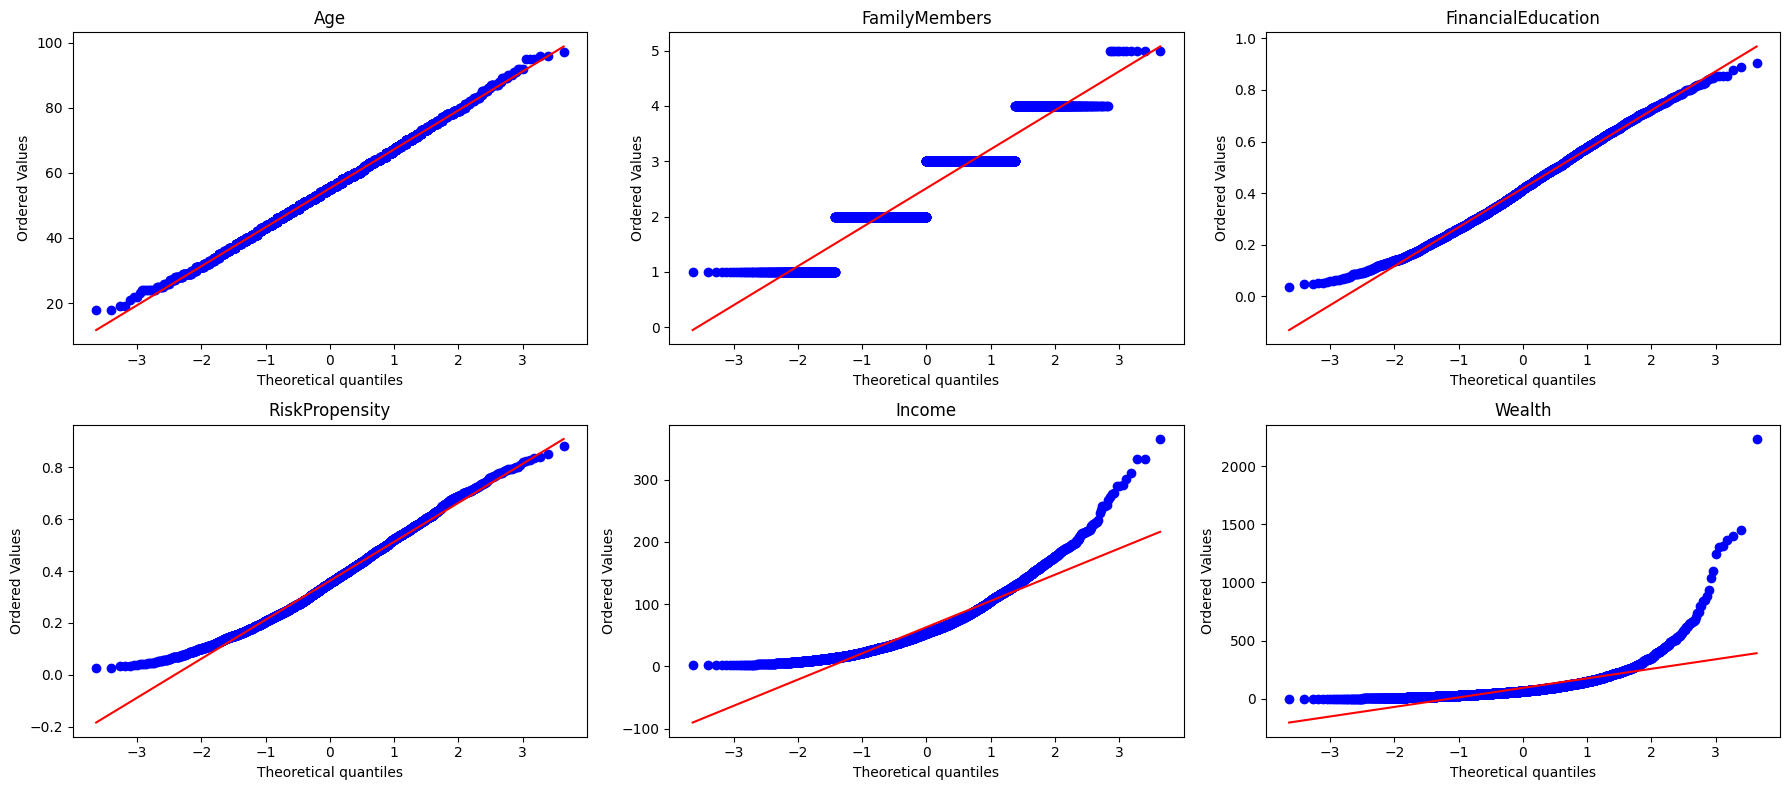

In [61]:
plot_qqplots(outlier_result, NUMERIC_COLS)

Each point compares an observed data quantile against the theoretical quantile of a normal distribution. If the points follow the red diagonal closely, the variable is approximately normal. Upward curvature at the right end indicates a heavier right tail than normal, which is the typical pattern for monetary variables.

The QQ plots reveal two types of behavior in the data:

- On the one hand, Age, FinancialEducation, and RiskPropensity generally follow a near-normal distribution, as evidenced by the alignment of the points around the line, despite slight deviations at the extremes (tails).

- On the other hand, Income and Wealth deviate significantly from this line, with a marked upward curve, revealing significant asymmetry and the presence of large extreme values (heavy tails). Finally, FamilyMembers stands out with its stepped structure, typical of a discrete variable, which explains the lack of continuous alignment. Overall, these graphs confirm that only certain variables can be considered quasi-Gaussian, while financial variables require transformations (particularly logarithmic transformations) to be properly analyzed.

Finaly, although financial features are highly informative but require transformations (e.g., logarithmic scaling) to stabilize their distribution. Additionally, the dataset shows strong heterogeneity in feature scales, making normalization essential before training a neural network.

# 7. Data Transformation

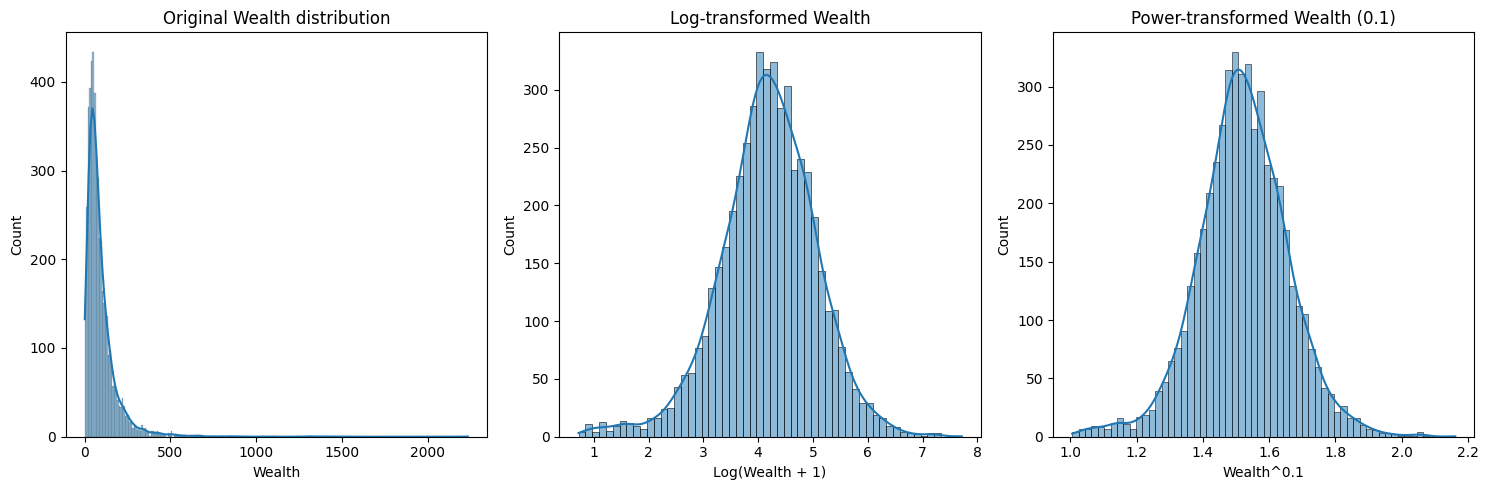

In [33]:
# Wealth transformation analysis
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Original distribution
sns.histplot(outlier_result.X_inliers.Wealth, kde=True, ax=ax1)
ax1.set_title('Original Wealth distribution')
ax1.set_xlabel('Wealth')

# Log transformation
sns.histplot(np.log1p(outlier_result.X_inliers.Wealth), kde=True, ax=ax2)
ax2.set_title('Log-transformed Wealth')
ax2.set_xlabel('Log(Wealth + 1)')

# Power transformation
sns.histplot(np.power(outlier_result.X_inliers.Wealth, 0.1), kde=True, ax=ax3)
ax3.set_title('Power-transformed Wealth (0.1)')
ax3.set_xlabel('Wealth^0.1')

plt.tight_layout()
plt.show()


We consider that the classes can be assumed as balanced, even if the first one is slightly asymmetric. In terms of normalisation, we are going to investigate which normalisation method is more adequate to obtain the nearest skewness from 0 by checking different values for the power. 

--- Statistics for Wealth ---
Original Skewness:    5.830
Log(x+1) Skewness:    -0.371
Optimal Power (0.124): 0.002
------------------------------


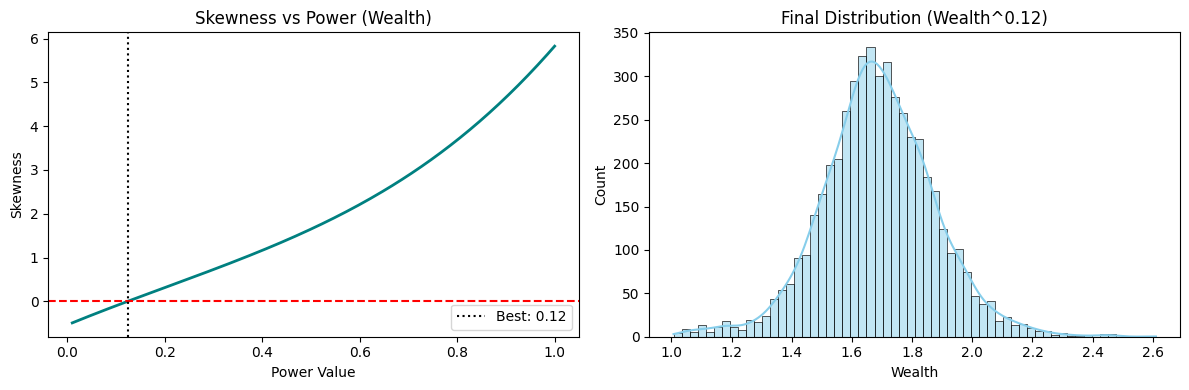

--- Statistics for Income ---
Original Skewness:    1.377
Log(x+1) Skewness:    -0.617
Optimal Power (0.313): 0.004
------------------------------


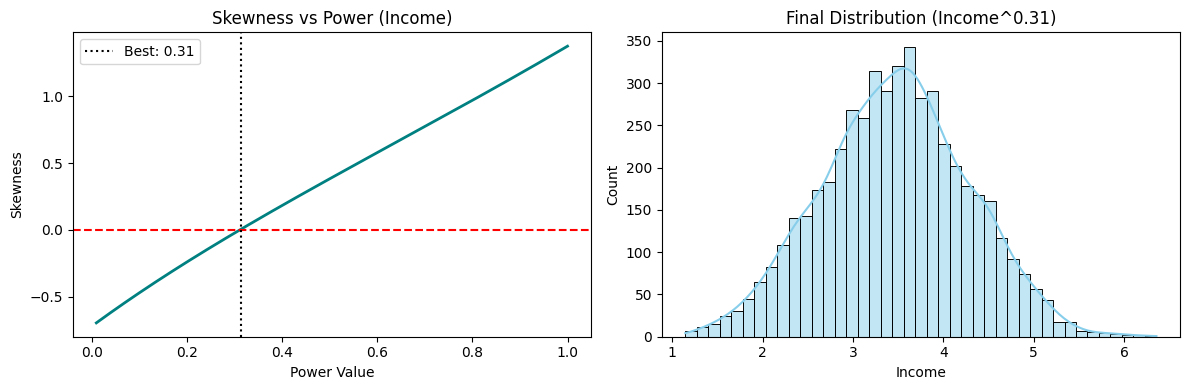

In [34]:
# Define the features to optimize
targets = ['Wealth', 'Income']
powers = np.linspace(0.01, 1.0, 200)
best_powers = {}


for col in targets:
    skewness_results = []
    data_clean = outlier_result.X_inliers[col].dropna()

    # Baseline Comparisons
    orig_skew = skew(data_clean)
    log_skew = skew(np.log1p(data_clean))

    # Iterate and calculate skewness for Power search
    for p in powers:
        transformed_data = np.power(data_clean, p)
        skewness_results.append(skew(transformed_data))

    # Find optimal power
    best_index = np.argmin(np.abs(skewness_results))
    best_power = powers[best_index]
    best_powers[col] = best_power

    # Print Comparison Statistics
    print(f"--- Statistics for {col} ---")
    print(f"Original Skewness:    {orig_skew:.3f}")
    print(f"Log(x+1) Skewness:    {log_skew:.3f}")
    print(f"Optimal Power ({best_power:.3f}): {skewness_results[best_index]:.3f}")
    print("-" * 30)

    # Visualization
    plt.figure(figsize=(12, 4))

    # Skewness Curve
    plt.subplot(1, 2, 1)
    plt.plot(powers, skewness_results, color='teal', lw=2)
    plt.axhline(0, color='red', linestyle='--')
    plt.axvline(best_power, color='black', linestyle=':', label=f'Best: {best_power:.2f}')
    plt.title(f'Skewness vs Power ({col})')
    plt.xlabel('Power Value')
    plt.ylabel('Skewness')
    plt.legend()

    # Final Distribution
    plt.subplot(1, 2, 2)
    sns.histplot(np.power(data_clean, best_power), kde=True, color='skyblue', edgecolor='black')
    plt.title(f'Final Distribution ({col}^{best_power:.2f})')

    plt.tight_layout()
    plt.show()

# Apply the transformations to the new columns
for col, p in best_powers.items():
    outlier_result.X_inliers[f'{col}_pow'] = np.power(outlier_result.X_inliers[col], p)


We tested multiple Power Transformations to normalize the heavily skewed Wealth variable (Original Skew: 5.83) and Income variable (Original Skew: 1.377). We found that a Power Transformation of 0.124 for wealth and 0.313 for income yielded the most symmetric distribution (Skew: 0.00).

In [68]:
def plot_log_distributions(df, features):

    fig, axes = plt.subplots(1, len(features), figsize=(6 * len(features), 4))

    if len(features) == 1:
        axes = [axes]

    for i, feat in enumerate(features):
        data = df[feat].dropna()
        log_data = np.log1p(data)

        sns.histplot(log_data, kde=True, ax=axes[i], color="darkorange", bins=50)

        axes[i].set_title(
            f"{feat} \nskew={log_data.skew():.2f}"
        )

    plt.suptitle("Log Transformation of Monetary Variables", fontsize=14)

    plt.tight_layout()

    plt.show()

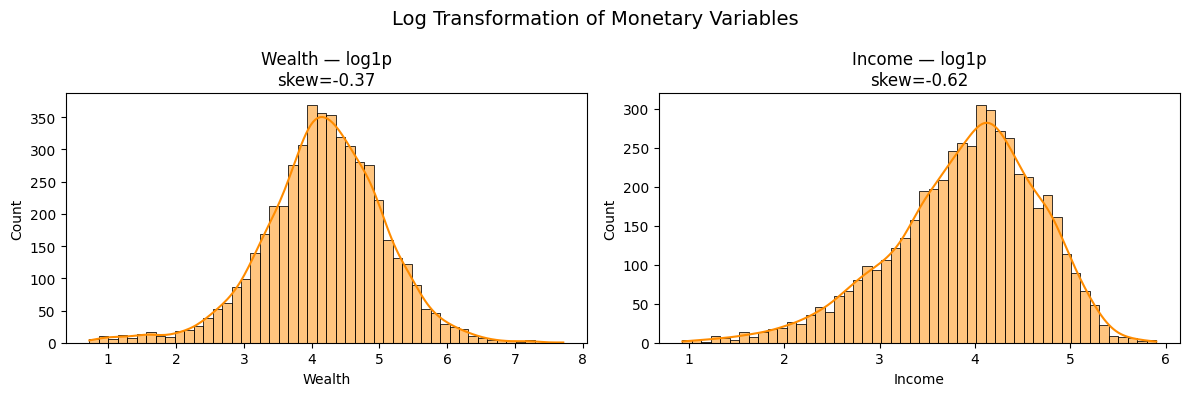

In [69]:
plot_log_distributions(outlier_result.X_inliers, ["Wealth", "Income"])

Despite the skweness results for power transformation, we prefer to use an logarithmic one for interpretability reasons as the order of magnitude is preserved. The differences between values correspond to ratios, which is particularly relevant for financial variables such as income or wealth. Conversely, a power transformation depends on a parameter estimated from the data, making it more difficult to explain and link to a clear business interpretation.